In [5]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot

import os
import scipy
import awkward as ak
import time

import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *

import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0
import matplotlib.pyplot as plt

from pathlib import Path
print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


# Load ntuples

In [6]:
%%time

fpath =OrderedDict()
tree = OrderedDict()

start_t = time.time()
version = "v33"
LUMI_SCALE = 1
# for data_year in ['2022','2023','all']:
for data_year in ['2024']:
    if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
    else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
    if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco_goodLumi.root"
    elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
    elif data_year == '2024':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2024-PromptReco_goodLumi.root"
    elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"
# path_sig = f"/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/"
# mass = [1, 7, 15,23,30,40,55]
# ctau = [1,10,100,1000,10000,100000]
# decay = ['B', 'D', 'Tau']
# for d in decay:
#     for m in mass:
#         if d == 'B' and m < 15:continue
#         if d == 'Tau' and m < 7:continue
#         for ct in ctau:
#             fpath[f'{d}_{m}_{ct}'] = f'{path_sig}/ggH_Hto2Sto4{d}_MH-125-MS-{m}-ctauS-{ct}_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root'
fpath['signal']='/storage/af/user/christiw/HNL_tauType_mHNL2p0_pl1000.root'
NEvents = {}
for k,v in fpath.items():
    print (k, v)
    if not os.path.isfile(v):continue
    root_dir = uproot.open(v) 
    # print(root_dir.keys())
    # if 'MuonSystem' not in root_dir.keys():continue
    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print("NEvents",NEvents[k])


data2024 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data2024/v33/normalized/Muon-EXOCSCCluster_Run2024-PromptReco_goodLumi.root
NEvents 3589282000.0
signal /storage/af/user/christiw/HNL_tauType_mHNL2p0_pl1000.root
NEvents 287426.4
CPU times: user 681 ms, sys: 15.6 ms, total: 696 ms
Wall time: 695 ms


In [7]:
def deltaPhi_test(phi1,phi2):
    dphi = np.array(phi1-phi2)
    while np.count_nonzero(dphi > math.pi)>0:
        dphi[dphi > math.pi] -= 2*math.pi
    while np.count_nonzero(dphi< -math.pi)>0:
        dphi[dphi < -1*math.pi] += 2*math.pi
    return dphi


# apply selections

In [8]:
%%time


JET_PT_CUT = 30
MUON_PT_CUT = 30.0

met = {}

cscRechitClusterPhi0 = {}
cscRechitClusterPhi1 = {}
deltaPhi_cluster  = {}
deltaR_cluster  = {}
cscRechitClusterJetVetoPt = {}
cscRechitClusterMuonVetoPt = {}
cscRechitClusterDNN0  = {}
cscRechitClusterDNN1  = {}
cscRechitClusterTime0  = {}
cscRechitClusterTime1  = {}
cscRechitClusterSize0  = {}
cscRechitClusterSize1  = {}
cscRechitClusterEta = {}
cscRechitClusterNStation = {}
weight = {}
gLLP_ctau = {}
HMTEff = {}
sel_ev = {}
sel = {}
cscRechitClusterMe1 = {}
deltaPhi_tau_cluster = {}
cscRechitClusterPuppiMet_dPhi = {}
tauPhi = {}
tauPt = {}
deltaEta_tau_cluster = {}
tauEta = {}
for k in tree.keys():
    T = tree[k]
    # if "data" in k:continue
    if 'data' in k: cluster_index = 'cscRechitCluster'
    else: cluster_index = 'cscRechitCluster3'
    

########### SELECTION: CLUSTERS ############
    if "data" in k: me1 = (T[f'{cluster_index}NRechitChamberPlus11'].array()+ T[f'{cluster_index}NRechitChamberPlus12'].array()+\
    T[f'{cluster_index}NRechitChamberMinus11'].array()+ T[f'{cluster_index}NRechitChamberMinus12'].array())
    else:
        me1 = T['cscRechitCluster3Me12Ratio'].array()*T['cscRechitCluster3Size'].array() + T['cscRechitCluster3Me11Ratio'].array()*T['cscRechitCluster3Size'].array()
    # cluster = 
    #one cluster to pass trigger
    # cluster0 = np.logical_and(T[f'{cluster_index}TimeWeighted'].array() < 12.5, T[f'{cluster_index}TimeWeighted'].array() > -5)
    # cluster = (T[f'{cluster_index}TimeSpreadWeightedAll'].array()<25)
    cluster = np.logical_and(T[f'{cluster_index}Time'].array() < 12.5, T[f'{cluster_index}Time'].array() > -5)
    cluster = cluster & (T[f'{cluster_index}JetVetoPt'].array()<JET_PT_CUT)
    cluster = cluster & (T[f'{cluster_index}MuonVetoPt'].array() < 30) 
    cluster = cluster & (T[f'{cluster_index}Size'].array() >= 100) 
    if not "data" in k:
        cluster = cluster & (T[f'{cluster_index}_match_gLLP_csc'].array())
        
    
    
    if "data" in k:tau = T['tauIsLoose'].array()
    else: 
        tau = (np.abs(T['gLepId'].array()) == 15)
        tau = tau & (np.abs(T['gLepEta'].array()) <2.3)
        tau = tau & (np.abs(T['gLepPt'].array()) >18)
        

    
            
########### SELECTION: EVENTS ############
    if "data" in k: 
        sel_ev[k] = T['HLT_CscCluster100_PNetTauhPFJet10_Loose'].array()
        sel_ev[k] = np.logical_and(sel_ev[k],T['jetVeto'].array())
        sel_ev[k] = np.logical_and(sel_ev[k],T['Flag_ecalBadCalibFilter'].array())
        sel_ev[k] = np.logical_and(sel_ev[k],T['Flag_all'].array())
        sel_ev[k] = np.logical_and(sel_ev[k],np.sum(tau, axis = 1) >= 1) # at least one passes HLT
        print(k, "data")
    else: 
        sel_ev[k] = T['runNum'].array()==1
        sel_ev[k] = np.logical_and(sel_ev[k],tau)

    print(k, np.count_nonzero(sel_ev[k]))
    sel_ev[k]  = np.logical_and(sel_ev[k],np.sum(cluster, axis = 1) >= 1) # at least one passes HLT
    print(k, np.count_nonzero(sel_ev[k]))
########### BRANCHES ############
   ##### event variables ##### 
    if 'data' in k:
        met[k] = T['Puppimet'].array()[sel_ev[k]]
        cscRechitClusterPuppiMet_dPhi[k] = T[f'{cluster_index}PuppiMet_dPhi'].array()[cluster][sel_ev[k]][:,0]
        tauPhi[k] = T['tauPhi'].array()[tau][sel_ev[k]][:,0]
        tauPt[k] = T['tauPt'].array()[tau][sel_ev[k]][:,0]
        tauEta[k] = T['tauEta'].array()[tau][sel_ev[k]][:,0]
    else: 
        met[k] = T['met'].array()[sel_ev[k]]
        cscRechitClusterPuppiMet_dPhi[k] = T[f'{cluster_index}Met_dPhi'].array()[cluster][sel_ev[k]][:,0]
        tauPhi[k] = T['gLepPhi'].array()[sel_ev[k]]
        tauPt[k] = T['gLepPt'].array()[sel_ev[k]]
        tauEta[k] = T['gLepEta'].array()[sel_ev[k]]
        gLLP_ctau[k] = T['gLLP_ctau'].array()[sel_ev[k]][:,0]
    cscRechitClusterPhi0[k] = T[f'{cluster_index}Phi'].array()[cluster][sel_ev[k]][:,0]
    # cscRechitClusterDNN0[k] = T[f'{cluster_index}DNN_bkgMC_plusBeamHalo'].array()[cluster][sel_ev[k]][:,0]
   
    cscRechitClusterSize0[k] = T[f'{cluster_index}Size'].array()[cluster][sel_ev[k]][:,0]
    cscRechitClusterEta[k] = T[f'{cluster_index}Eta'].array()[cluster][sel_ev[k]][:,0]
    cscRechitClusterMuonVetoPt[k] = T[f'{cluster_index}MuonVetoPt'].array()[cluster][sel_ev[k]][:,0]
    cscRechitClusterJetVetoPt[k] = T[f'{cluster_index}JetVetoPt'].array()[cluster][sel_ev[k]][:,0]
    cscRechitClusterMe1[k] = me1[cluster][sel_ev[k]][:,0]
    


    
    deltaPhi_tau_cluster[k] = deltaPhi_test(cscRechitClusterPhi0[k], tauPhi[k])
    deltaEta_tau_cluster[k] = cscRechitClusterEta[k] - tauEta[k]

    
    weight[k] = (T['weight'].array())[sel_ev[k]]*0.0 + 1                                                             
    if 'signal' in k:
        weight[k] = (T['weight'].array())[sel_ev[k]]/NEvents[k]*109000*1
    print(k, len(weight[k]), NEvents[k])
    

data2024 data
data2024 613505
data2024 422275
data2024 422275 3589282000.0
signal 100544
signal 944
signal 944 287426.4
CPU times: user 12.6 s, sys: 4.5 s, total: 17.1 s
Wall time: 19.5 s


In [9]:
variables = {
f'{cluster_index}Me1': ['CSC cluster N_{ME11/12 hits}', cscRechitClusterMe1, [50,0,50], True],
f'{cluster_index}JetVetoPt': ['CSC cluster jet veto p_{T} [GeV]', cscRechitClusterJetVetoPt, [50,0,50], True],
# f'{cluster_index}GlobalMuonVetoPt': ['CSC cluster muon veto p_{T} [GeV]', cscRechitClusterGlobalMuonVetoPt, [30,0,300], True],
f'{cluster_index}MuonVetoPt': ['CSC cluster muon veto p_{T} [GeV]', cscRechitClusterMuonVetoPt, [50,0,100], True],
# f'{cluster_index}NStation': ['CSC cluster  N_{stations}', cscRechitClusterNStation, [5,0,5], True],
f'{cluster_index}Phi': ['CSC cluster #phi', cscRechitClusterPhi0, [50,-3.5,3.5], True],
f'{cluster_index}Eta': ['CSC cluster #eta', cscRechitClusterEta, [50,-3,3], True],
f'{cluster_index}DNN': ['CSC cluster DNN score', cscRechitClusterDNN0, [50,0,1], True],
# f'{cluster_index}Time': ['CSC cluster time [ns]', cscRechitClusterTime, [50,-100,100], False],
# f'{cluster_index}TimeSpread': ['CSC cluster time spread [ns]', cscRechitClusterTimeSpread, [50,0,50], True],
f'{cluster_index}Size': ['CSC cluster N_{hits}', cscRechitClusterSize0, [50,0,500], True],
f'{cluster_index}Met_dPhi': ['#Delta#phi(MET, cluster)', cscRechitClusterPuppiMet_dPhi, [25,0,3.2], True],

"Puppimet": ['MET [GeV]', met, [50,0,200],True],
"tauEta": ['tau #eta', tauEta, [50,-2.5,2.5],True],
"tauPt": ['tau pt [GeV]', tauPt, [50,0,100],True],
"tauPhi": ['tau phi', tauPhi, [50,-3.2,3.2],True],
"deltaPhi_tau_cluster": ["dPhi(tau,cluster)", deltaPhi_tau_cluster,[50,-3.2,3.2],True],
"deltaEta_tau_cluster": ["dEta(tau,cluster)", deltaEta_tau_cluster,[50,-6,6],True],

}
plot_dir = GIT_REPO + f"/plots/selections_hnl_tau/"
Path(plot_dir).mkdir(parents=True, exist_ok=True)

[50, 0, 500]
[50, 0, 500]
21.054665327072144


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_hnl_tau//cscRechitCluster3Size.png has been created
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_hnl_tau//cscRechitCluster3Size.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_hnl_tau//cscRechitCluster3Size.C has been generated


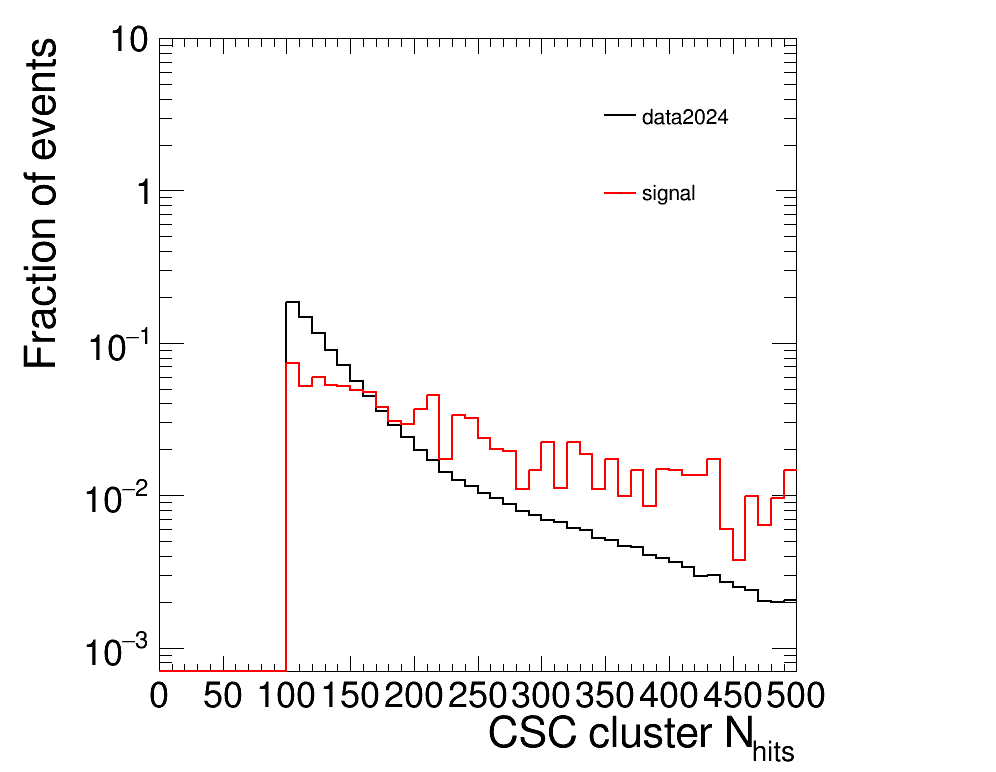

In [10]:

for name, v in variables.items():
    if not "Size" in name:continue

    c = rt.TCanvas('c1','c', 1000, 800)
    h = {}
    leg = rt.TLegend(0.6,0.7,0.78,0.9)
    leg.SetTextSize(0.03)
    leg.SetTextFont(42)
    leg.SetBorderSize(0)
    xaxis, plot_var, bins, logy = v
    i = 0
    for k in plot_var.keys():
        print(bins)

        h[k] = create_TH1D( np.array(plot_var[k]), axis_title = [xaxis,'Fraction of events'], binning=bins,weights = np.array(weight[k]))

        if h[k].Integral()>0: h[k].Scale(1./h[k].Integral())
        if logy: h[k].SetMaximum(10)
        else: h[k].SetMaximum(1)
        if "Puppi" in name: h[k].SetMinimum(1e-5)
        else: h[k].SetMinimum(7e-4)
        # print(np.count_nonzero(np.array(plot_var[k][cond])>0)/len(np.array(plot_var[k][cond])))
        h[k].SetLineColor(std_color_list[i])
        leg.AddEntry(h[k],k)
        # else: leg.AddEntry(h[k],k.replace('_inclusive',''))
        h[k].Draw('hist same')
        i+=1
    c.SetRightMargin(0.2)

    if logy: c.SetLogy()
    leg.Draw()
    c.Draw()

    c.SaveAs(plot_dir + f"/{name}.png")
    c.SaveAs(plot_dir + f"/{name}.pdf")
    c.SaveAs(plot_dir + f"/{name}.C")
    # break


print(time.time()-start_t)


In [11]:
target = [10,50,100,500,1000,5000,10000]
original = 1000 ## mm
paths = "/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HNL"

In [21]:
cond = {}
for k in tauPt.keys():
    cond[k] = (tauPt[k]>30) & (np.abs(deltaPhi_tau_cluster[k])>2)&  (cscRechitClusterSize0[k]>160) & (np.abs(deltaEta_tau_cluster[k])<2) & (np.abs(cscRechitClusterPuppiMet_dPhi[k])<1.5)
    # print(k, np.sum(weight[k][cond]), np.count_nonzero(cond)/len(cond))
for ct in target:
    w = weight_calc(gLLP_ctau[k], ct/10., original/10., 1) * weight[k]
    write_card(f"{paths}/HNL_2GeV_ct{ct}.txt", np.sum(w[cond["signal"]]), np.count_nonzero(cond["data2024"]))
    print(ct, np.sum(w[cond["signal"]]))
    # os.system(f"combine -M AsymptoticLimits --run blind {paths}/HNL_2GeV_ct{ct}.txt")

10 0.48662258371628725
50 207.23148963066882
100 409.9827748471504
500 314.3990547119023
1000 190.28578961837323
5000 44.54118801809573
10000 22.71955515978516


In [18]:
gLLP_ctau

{'signal': <Array [25.7, 13.9, 32.5, ... 12.6, 37.9, 15.2] type='944 * float32'>}

In [13]:
def weight_calc(llp_ct, new_ctau, old_ctau, nLLP = 1, flag = False):
    source = np.exp(-1.0*llp_ct/old_ctau)/old_ctau**nLLP
    weight = 1.0/new_ctau**nLLP * np.exp(-1.0*llp_ct/new_ctau)/source
    return weight


In [20]:
def write_card(file_name, sig, bkg, norm = 1):
    with open(file_name, "w") as file:
        file.write("imax 1  number of channels\n")
        file.write("jmax 1  number of backgrounds\n")
        file.write("kmax 1  number of nuisance parameters (sources of systematical uncertainties)\n")
        file.write("------------\n")
        file.write("bin bin1\n")
        file.write("observation 0\n")
        file.write("------------\n")
        file.write("bin             bin1 bin1\n")
        file.write("process         ggH  bkg\n")
        file.write("process          0    1\n")
        file.write(f"rate           {sig}  {bkg}\n")
        file.write("------------\n")
        file.write("xs_ggH  lnN    1.16    -\n")


[]

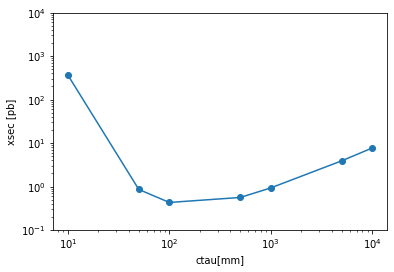

In [26]:
ctaus = [10,50,100,500,1000,5000,10000]
limits = [364,0.855,0.43,0.56,0.93,3.9,7.7]




# Plot the data
plt.plot(ctaus, limits, marker='o')

# Add labels and title (optional)
plt.xlabel('ctau[mm]')
plt.ylabel('xsec [pb]')
plt.ylim(10e-2,10e3)
plt.loglog()
# plt.show()

In [27]:
## function for tau
def f_1m_tau(x):
    x0 = np.array([1,2,4,7,10])
    y0 = np.array([30700,963,17.9,0.646,0.0912])/1000.
    return np.exp(np.poly1d(np.polyfit(x0,np.log(y0),4))(x))

## return a function of f(ctau[mm]) = pb for mass m[GeV]
def f_xsec_tau(m):
    def xsec_m_tau(x):
        return f_1m_tau(m)/(x/1000.)
    return xsec_m_tau
## return a function of f(ctau[mm]) = V2  for mass m[GeV]
def f_v2_tau(m):
    def ctau_m_tau(x):
        return f_xsec_tau(m)(x)*4.8759E-05 ## const. between xsec and v^2
    return ctau_m_tau

In [40]:
f_v2_tau(2)(1000)

4.69549169999994e-05

In [41]:
f_v2_tau(2)(20)

0.0023477458499999698